# Wave Field Animation: PEC Cylinders

Generates a wave field visualization for a slab of **PEC cylinders** ($\varepsilon = -1$).

PEC cylinders are perfect reflectors — waves bounce off completely. This makes them
much stronger scatterers than dielectric cylinders, resulting in lower transmission
for normal incidence but dramatic improvement with the optimal wavefront.

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from scipy.special import hankel2 as hankel2_scipy

sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.jax.smatrix import smatrix, _vall_batch
from Scattering_Code.jax.transall import transall
from Scattering_Code.jax.sall import sall
from Scattering_Code.jax.ky import ky

In [2]:
WAVELENGTH = 0.93
PERIOD     = 12.81
RADIUS     = 0.25
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2
NUM_CYL    = 50
SEED       = 42
GRID_RES   = 200
PR_Y       = 7

nmax = int(np.floor(PERIOD / WAVELENGTH))  # PEC: propagating only
nm   = 2 * nmax + 1
n_eva = 0

## 1. Setup and Compute S-Matrix

In [3]:
spacing = 2.5 * RADIUS
cyls_per_row = int(PERIOD / spacing)
rows_needed = NUM_CYL / cyls_per_row + 2
thickness = round(max(0.5, rows_needed * spacing * 1.5), 1)

rng = np.random.RandomState(SEED)
margin = RADIUS * 1.5
min_sep = 2.5 * RADIUS
clocs = np.zeros((NUM_CYL, 2))
for i in range(NUM_CYL):
    for _ in range(10000):
        x = margin + rng.rand() * (PERIOD - 2*margin)
        y = margin + rng.rand() * (thickness - 2*margin)
        if i == 0 or np.all(np.sqrt((x - clocs[:i, 0])**2 + (y - clocs[:i, 1])**2) > min_sep):
            clocs[i] = [x, y]
            break

sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)
cmmaxs = np.full(NUM_CYL, CMMAX, dtype=int)
cepmus = np.column_stack([np.full(NUM_CYL, -1.0), np.full(NUM_CYL, MU)])  # PEC
crads  = np.full(NUM_CYL, RADIUS)

print(f"Computing S-matrix ({NUM_CYL} PEC cylinders)...")
t0 = time.time()
S, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH, nmax, thickness, sp, 'On')
S = np.array(S)
        
print(f"Done in {time.time()-t0:.1f}s")

Computing S-matrix (50 PEC cylinders)...


/Users/thirulok/Documents/CyScat_Julia/CyScat/python_jax/CyScat/examples/generate_wave_demo_pec/../../Scattering_Code/smatrix.py:52: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  clocs = jnp.asarray(clocs, dtype=jnp.float64)
/opt/anaconda3/lib/python3.13/site-packages/jax/_src/numpy/lax_numpy.py:5982: UserWarning: Explicitly requested dtype float64 requested in arange is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return _arange(start, stop=stop, step=step, dtype=dtype,
/opt/anaconda3/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py

  Computing T-Matrix...


W0414 09:58:53.467998 10863520 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
/Users/thirulok/Documents/CyScat_Julia/CyScat/python_jax/CyScat/examples/generate_wave_demo_pec/../../Scattering_Code/transall.py:56: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  clocs = jnp.asarray(clocs, dtype=jnp.float64)
/Users/thirulok/Documents/CyScat_Julia/CyScat/python_jax/CyScat/examples/generate_wave_demo_pec/../../Scattering_Code/bessel_jax.py:172: UserWarning: Explicitly requested dtype complex128 requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell e

  transall: 1225 pairs (1158 spectral, 67 spatial)
  T-Matrix: 46.8s


/Users/thirulok/Documents/CyScat_Julia/CyScat/python_jax/CyScat/examples/generate_wave_demo_pec/../../Scattering_Code/sall.py:36: UserWarning: Explicitly requested dtype complex128 requested in zeros is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  s = jnp.zeros(tot_no_modes, dtype=jnp.complex128)
/opt/anaconda3/lib/python3.13/site-packages/jax/_src/numpy/lax_numpy.py:5840: UserWarning: Explicitly requested dtype complex128 requested in eye is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  output = _eye(N, M=M, k=k, dtype=dtype)


  Solving linear system...
  Solve: 1.9s
  Computing S11 & S21...
  S11&S21: 1.1s
  Computing S12 & S22...
  S12&S22: 0.3s
  Total: 51.2s (0.9 min)
Done in 70.0s


## 2. Transmission Eigenvalue Distribution

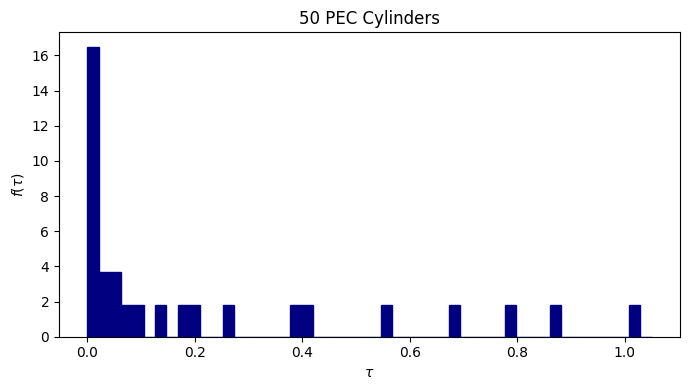

In [4]:
S11 = S[:nm, :nm]
S21 = S[nm:, :nm]
tau = svd(S21, compute_uv=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tau, bins=50, range=(0, 1.05), density=True, color='navy', edgecolor='navy')
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$f(\tau)$')
ax.set_title(f'{NUM_CYL} PEC Cylinders')
plt.tight_layout()
plt.savefig('pec_tau_distribution.png', dpi=150)
plt.show()

## 3. Build Wave Fields

In [5]:
def build_field(S, nmax, thickness, mode, clocs, crads, cmmaxs, cepmus, sp):
    """
    Compute the wave field for PEC cylinders (no evanescent modes).
    Interior field: incident Floquet + Hankel expansion from each cylinder.
    Field is 0 inside cylinders (PEC).
    """
    nm   = 2 * nmax + 1
    S11  = S[:nm, :nm]
    S21  = S[nm:, :nm]

    # ── Input wavefront ──────────────────────────────────────────────────────
    if mode == 'opt_trans':
        _, _, Vh = svd(S11)
        v_in  = Vh.conj().T[:, -1]
        tc    = np.sum(np.abs(S21 @ v_in)**2)
        label = f'Optimal Wavefront — {tc*100:.1f}% transmitted'
    else:
        v_in        = np.zeros(nm, dtype=complex)
        v_in[nmax]  = 1.0
        tc          = np.sum(np.abs(S21[:, nmax])**2)
        label = f'Normal Incidence — {tc*100:.1f}% transmitted'

    Input = v_in

    # ── Floquet mode parameters ───────────────────────────────────────────────
    k    = 2 * np.pi / WAVELENGTH
    m_f  = np.arange(-nmax, nmax + 1)
    kxs  = 2 * np.pi / PERIOD * m_f
    kys  = ky(k, kxs.astype(complex))
    P1   = np.diag(1.0 / np.sqrt(kys / k))
    Inc_c = P1 @ Input
    Ref_c = P1 @ (S11 @ Input)
    Tra_c = P1 @ (S21 @ Input)

    # ── Re-solve multiple scattering → per-cylinder coefficients c_vector ────
    total_steps = len(cmmaxs) * (len(cmmaxs) - 1) // 2 + 2 * nm
    t_mat  = np.array(transall(clocs, cmmaxs, PERIOD, WAVELENGTH, sp['phiinc'], sp, total_steps))
    s_vec  = np.array(sall(cmmaxs, cepmus, crads, WAVELENGTH))
    z      = np.eye(len(s_vec)) - np.diag(s_vec) @ t_mat

    kxex_all = np.array([
        float(np.array(sp['kxs']).flatten()[sp['MiddleIndex'] + nin])
        for nin in range(-nmax, nmax + 1)
    ])
    V_up     = np.array(_vall_batch(clocs, cmmaxs, kxex_all, k, up_down=1))
    v_excite = s_vec * (V_up @ Input)
    c_vector = np.linalg.solve(z, v_excite)

    starts = np.concatenate([[0], np.cumsum(2 * cmmaxs + 1)[:-1]])

    # ── Build grid ────────────────────────────────────────────────────────────
    Nx     = GRID_RES
    Ly     = PR_Y * WAVELENGTH
    y_full = np.linspace(-Ly, thickness + Ly, GRID_RES * 2)
    x_phys = np.linspace(0, PERIOD, Nx)
    Field  = np.zeros((Nx, len(y_full)), dtype=complex)

    for jy, y in enumerate(y_full):
        for ix in range(Nx):
            x = x_phys[ix]

            if y < 0:
                Field[ix, jy] = (
                    np.sum(Inc_c * np.exp(1j * (-kxs*x - kys*y))) +
                    np.sum(Ref_c * np.exp(1j * (-kxs*x + kys*y)))
                )
            elif y > thickness:
                Field[ix, jy] = np.sum(
                    Tra_c * np.exp(1j * (-kxs*x - kys*(y - thickness)))
                )
            else:
                total_f = np.sum(Inc_c * np.exp(1j * (-kxs*x - kys*y)))
                inside  = False
                for i in range(len(crads)):
                    dx = x - clocs[i, 0]
                    dy = y - clocs[i, 1]
                    r  = np.sqrt(dx**2 + dy**2)
                    if r <= crads[i]:
                        inside = True
                        break
                    theta   = np.arctan2(dy, dx)
                    m_max_i = int(cmmaxs[i])
                    i0      = starts[i]
                    for m_idx in range(-m_max_i, m_max_i + 1):
                        total_f += (c_vector[i0 + m_idx + m_max_i] *
                                    hankel2_scipy(m_idx, k * r) *
                                    np.exp(1j * m_idx * theta))
                Field[ix, jy] = 0.0 if inside else total_f

    return Field, x_phys / WAVELENGTH, y_full / WAVELENGTH, label


In [ ]:
print("Building normal incidence field (includes cylinder scattering)...")
t0 = time.time()
F_norm, x_grid, y_grid, label_norm = build_field(
    S, nmax, thickness, 'normal', clocs, crads, cmmaxs, cepmus, sp)
print(f"  {label_norm}  [{time.time()-t0:.1f}s]")

print("Building optimal wavefront field...")
t0 = time.time()
F_opt, _, _, label_opt = build_field(
    S, nmax, thickness, 'opt_trans', clocs, crads, cmmaxs, cepmus, sp)
print(f"  {label_opt}  [{time.time()-t0:.1f}s]")


Building normal incidence field (includes cylinder scattering)...


## 4. Plot Wave Fields

In [ ]:
vmax = max(np.max(np.abs(np.real(F_norm))), np.max(np.abs(np.real(F_opt)))) * 0.7

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, F, label in zip(axes, [F_norm, F_opt], [label_norm, label_opt]):
    im = ax.pcolormesh(y_grid, x_grid, np.real(F), cmap='jet', vmin=-vmax, vmax=vmax)
    ax.axvline(0, color='magenta', lw=2)
    ax.axvline(thickness / WAVELENGTH, color='magenta', lw=2)
    # Draw cylinder outlines
    theta = np.linspace(0, 2*np.pi, 40)
    for i in range(NUM_CYL):
        cx = clocs[i,1] / WAVELENGTH
        cy = clocs[i,0] / WAVELENGTH
        r_lam = RADIUS / WAVELENGTH
        ax.plot(cx + r_lam*np.cos(theta), cy + r_lam*np.sin(theta), 'k-', lw=0.8)
    ax.set_xlabel('y/lambda')
    ax.set_ylabel('x/lambda')
    ax.set_title(label)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('pec_wave_field.png', dpi=150)
plt.show()

## 5. Wave Animation

Animate the wave field by sweeping phase over one full cycle:
`Re(F · exp(-iφ))` for φ ∈ [0, 2π]. Both modes shown simultaneously.

In [ ]:
import matplotlib.animation as animation

N_FRAMES = 40
phases = np.linspace(0, 2*np.pi, N_FRAMES, endpoint=False)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

vmax_anim = max(np.max(np.abs(F_norm)), np.max(np.abs(F_opt))) * 0.7

theta = np.linspace(0, 2*np.pi, 40)

ims = []
for ax, F, label in zip(axes, [F_norm, F_opt], [label_norm, label_opt]):
    im = ax.pcolormesh(y_grid, x_grid, np.real(F), cmap='jet',
                       vmin=-vmax_anim, vmax=vmax_anim, shading='auto')
    ax.axvline(0, color='magenta', lw=2)
    ax.axvline(thickness / WAVELENGTH, color='magenta', lw=2)
    for i in range(NUM_CYL):
        cx = clocs[i, 1] / WAVELENGTH
        cy = clocs[i, 0] / WAVELENGTH
        r_lam = RADIUS / WAVELENGTH
        ax.plot(cx + r_lam * np.cos(theta), cy + r_lam * np.sin(theta), 'k-', lw=0.5)
    ax.set_xlabel(r'y/$\lambda$')
    ax.set_ylabel(r'x/$\lambda$')
    ax.set_title(label)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)
    ims.append(im)

plt.tight_layout()

def update(frame):
    phi = phases[frame]
    for im, F in zip(ims, [F_norm, F_opt]):
        im.set_array(np.real(F * np.exp(+1j * phi)))   # +1j: wave travels in +y
    return ims

anim = animation.FuncAnimation(fig, update, frames=N_FRAMES, interval=80, blit=True)

print("Saving pec_wave_animation.mp4 ...")
anim.save('pec_wave_animation.mp4', writer='ffmpeg', fps=15, dpi=120)
print("Saved: pec_wave_animation.mp4")
plt.close(fig)
